In [1]:
import ast
import concurrent.futures
import glob
import itertools
import os
import pickle
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

import dask
import dask.dataframe as dd
import dask_ml.cluster as dask_cluster
from dask.distributed import Client
from dask.diagnostics import ProgressBar

from concurrent.futures import ThreadPoolExecutor
from joblib import Parallel, delayed
from multiprocessing import Pool, cpu_count

from sklearn.linear_model import LinearRegression
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score
#from sklearn.cluster import KMeans

from statsmodels.regression.rolling import RollingOLS

from tqdm.notebook import tqdm
from collections import Counter
from functools import reduce
from pprint import pprint

pd.set_option('display.max_columns', None)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

### Load Feature Importance

In [2]:
feature_importance_df = pd.read_csv("feature_importance.csv")

In [3]:
feature_importance_df

,fips,log_rolled_cases.y,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,State_of_emergency_issued,State_of_emergency_lifted,Date_closed_K.12_public_schools,Closed_day_cares,Reopen_day_cares,Date_banned_visitors_to_nursing_homes,Stay_at_home._shelter_in_place,Stay_at_home_order._issued_but_did_not_specifically_restrict_movement_of_the_general_public,End.relax_stay_at_home.shelter_in_place,Closed_other_non.essential_businesses,Closed_businesses_overnight,Began_to_reopen_businesses,Religious_gatherings_exempt_without_clear_social_distance_mandate.,Face_mask_mandate_in_public_spaces,Face_mask_mandate_x2,Face_mask_mandate_enforced_by_fines,Face_mask_mandate_enforced_by_criminal_charge.citation,No_legal_enforcement_of_face_mask_mandate,Face_mask_mandate_for_employees_of_public.facing_businesses,Ended_face_mask_mandate,Ended_face_mask_mandate_x2,Attempted_to_prevent_local_governments_from_implementing_face_mask_orders,Banned_local_mask_mandates,Liquor_stores_remained_open,Allowed_restaurants_to_sell_takeout_alcohol,Allowed_restaurants_to_deliver_alcohol,Firearm_sellers_remained_open,Cannabis_dispensaries_considered_essential_business,Closed_restaurants_except_take_out,Reopen_restaurants,Initially_reopen_restaurants_for_outdoor_dining_only,Closed_gyms,Reopened_gyms,Closed_movie_theaters,Reopened_movie_theaters,Closed_Bars,Reopen_bars,Reopened_hair_salons.barber_shops,Reopened_religious_gatherings,Reopened_other_non.essential_retail,Allowed_businesses_to_reopen_overnight,Began_to_reclose_bars,Closed_bars_.x2.,Closed_movie_theaters_.x2.,Closed_hair_salons.barber_shops_.x2.,Closed_gyms_.x2.,Closed_restaurants_.x2.,Reopened_restaurants_.x2.,Reopened_bars_.x2.,Reopened_gyms_.x2.,Reopened_hair_salons.barber_shops_.x2.,Reopened_movie_theaters_.x2.,Closed_bars_.x3.,Closed_restaurants_.x3.,Reopened_bars_.x3.,Reopened_restaurants_.x3.,Mandate_quarantine_for_those_entering_the_state_from_specific_settings,Mandate_quarantine_for_all_individuals_entering_the_state,Date_all_mandated_quarantines_ended,Date_vaccine_allocation_plan_last_updated,Vaccine_allocation_phase._Frontline_Healthcare_Workers,Vaccine_allocation_phase._Healthcare_Service_Workers,Vaccine_allocation_phase._Home_Healthcare_Workers,Vaccine_allocation_phase._Additional_Healthcare_Workers,Vaccine_allocation_phase._Long.term_Care_Residents,Vaccine_allocation_phase._EMS_Providers,Vaccine_allocation_phase._Firefighters,Vaccine_allocation_phase._Law_Enforcement_._Public_Safety_Personnel,Vaccine_allocation_phase._Correctional_Staff,Vaccine_allocation_phase._People_who_are_Incarcerated,Vaccine_allocation_phase._Residents_of_Homeless_Shelters,Vaccine_allocation_phase._Adults_Ages_75.,Vaccine_allocation_phase._Adults_Ages_65.,Vaccine_allocation_phase._Adults_w._High.Risk_Medical_Conditions,Vaccine_allocation_phase._Pre.K.12_School_Employees,Vaccine_allocation_phase._Higher_Education_Employees,Vaccine_allocation_phase._Public_Transit_Workers,Vaccine_allocation_phase._Food_Supply_Workers,Vaccine_allocation_phase._Grocery_Store_Workers,Vaccine_allocation_phase._Frontline_Essential_Workers,Vaccine_allocation_phase._Additional_Essential_Workers,Vaccine_al

In [34]:
pd.DataFrame(feature_importance_df.loc[9]).sort_index()

,9
AREA_SQMI,0.00000
Adults_ages_65._prioritized_ahead_of_essential_workers,0.00000
Aerosol_transmissable_diseases_standards,0.00000
Air_or_ventilation_standards,0.00000
All.cause_deaths_2018,0.00025
...,...
totalTestsPeopleAntigen,0.00000
totalTestsPeopleViral,0.00000
totalTestsPeopleViralIncrease,0.00000
totalTestsViral,0.00000


In [4]:
exclusion_cols = ["fips", "log_rolled_cases.y", "cutoff", "t0.lm", "r.lm"]
filtered_feature_importance_df = feature_importance_df.drop(columns=exclusion_cols)
filtered_feature_importance_df.sum(axis=1)


0    0.749558
1    0.757805
2    0.815003
3    0.732762
4    0.765503
5    0.734729
6    0.772085
7    0.801564
8    0.830695
9    0.806341
dtype: float64

In [5]:
normalized_filtered_feature_importance_df = filtered_feature_importance_df.div(filtered_feature_importance_df.sum(axis=1), axis=0)
normalized_filtered_feature_importance_df

,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,State_of_emergency_issued,State_of_emergency_lifted,Date_closed_K.12_public_schools,Closed_day_cares,Reopen_day_cares,Date_banned_visitors_to_nursing_homes,Stay_at_home._shelter_in_place,Stay_at_home_order._issued_but_did_not_specifically_restrict_movement_of_the_general_public,End.relax_stay_at_home.shelter_in_place,Closed_other_non.essential_businesses,Closed_businesses_overnight,Began_to_reopen_businesses,Religious_gatherings_exempt_without_clear_social_distance_mandate.,Face_mask_mandate_in_public_spaces,Face_mask_mandate_x2,Face_mask_mandate_enforced_by_fines,Face_mask_mandate_enforced_by_criminal_charge.citation,No_legal_enforcement_of_face_mask_mandate,Face_mask_mandate_for_employees_of_public.facing_businesses,Ended_face_mask_mandate,Ended_face_mask_mandate_x2,Attempted_to_prevent_local_governments_from_implementing_face_mask_orders,Banned_local_mask_mandates,Liquor_stores_remained_open,Allowed_restaurants_to_sell_takeout_alcohol,Allowed_restaurants_to_deliver_alcohol,Firearm_sellers_remained_open,Cannabis_dispensaries_considered_essential_business,Closed_restaurants_except_take_out,Reopen_restaurants,Initially_reopen_restaurants_for_outdoor_dining_only,Closed_gyms,Reopened_gyms,Closed_movie_theaters,Reopened_movie_theaters,Closed_Bars,Reopen_bars,Reopened_hair_salons.barber_shops,Reopened_religious_gatherings,Reopened_other_non.essential_retail,Allowed_businesses_to_reopen_overnight,Began_to_reclose_bars,Closed_bars_.x2.,Closed_movie_theaters_.x2.,Closed_hair_salons.barber_shops_.x2.,Closed_gyms_.x2.,Closed_restaurants_.x2.,Reopened_restaurants_.x2.,Reopened_bars_.x2.,Reopened_gyms_.x2.,Reopened_hair_salons.barber_shops_.x2.,Reopened_movie_theaters_.x2.,Closed_bars_.x3.,Closed_restaurants_.x3.,Reopened_bars_.x3.,Reopened_restaurants_.x3.,Mandate_quarantine_for_those_entering_the_state_from_specific_settings,Mandate_quarantine_for_all_individuals_entering_the_state,Date_all_mandated_quarantines_ended,Date_vaccine_allocation_plan_last_updated,Vaccine_allocation_phase._Frontline_Healthcare_Workers,Vaccine_allocation_phase._Healthcare_Service_Workers,Vaccine_allocation_phase._Home_Healthcare_Workers,Vaccine_allocation_phase._Additional_Healthcare_Workers,Vaccine_allocation_phase._Long.term_Care_Residents,Vaccine_allocation_phase._EMS_Providers,Vaccine_allocation_phase._Firefighters,Vaccine_allocation_phase._Law_Enforcement_._Public_Safety_Personnel,Vaccine_allocation_phase._Correctional_Staff,Vaccine_allocation_phase._People_who_are_Incarcerated,Vaccine_allocation_phase._Residents_of_Homeless_Shelters,Vaccine_allocation_phase._Adults_Ages_75.,Vaccine_allocation_phase._Adults_Ages_65.,Vaccine_allocation_phase._Adults_w._High.Risk_Medical_Conditions,Vaccine_allocation_phase._Pre.K.12_School_Employees,Vaccine_allocation_phase._Higher_Education_Employees,Vaccine_allocation_phase._Public_Transit_Workers,Vaccine_allocation_phase._Food_Supply_Workers,Vaccine_allocation_phase._Grocery_Store_Workers,Vaccine_allocation_phase._Frontline_Essential_Workers,Vaccine_allocation_phase._Additional_Essential_Workers,Vaccine_allocation_phase._General_

In [6]:
sorted_feature_importance = pd.DataFrame((normalized_filtered_feature_importance_df.sum(axis=0)/normalized_filtered_feature_importance_df.shape[0]).sort_values(ascending=False))
sorted_feature_importance = sorted_feature_importance.rename(columns={0:"Importance (%)"})
sorted_feature_importance = sorted_feature_importance*100

In [25]:
sorted_feature_importance.head(20)

,Importance (%)
Stopped_personal_visitation_in_state_prisons,8.013022
State_of_emergency_issued,6.563644
SNAP_Waiver_._Emergency_Allotments_to_Current_SNAP_Households,5.398740
Date_closed_K.12_public_schools,5.341139
Closed_Bars,4.523039
Modify_Medicaid_requirements_with_1135_waivers_.date_of_CMS_approval.,3.951363
Closed_gyms,3.703256
Closed_restaurants_except_take_out,3.615671
Closed_other_non.essential_businesses,3.477452
Allow.expand_Medicaid_telehealth_coverage,3.248397


In [7]:
sorted_feature_importance.head(10).sum(), sorted_feature_importance.head(20).sum()

(Importance (%)    47.835723
 dtype: float64,
 Importance (%)    66.580315
 dtype: float64)

In [8]:
new_names_top_10 = [
    'Stopped Personal Visitation in State Prisons',
    'State of Emergency Issued',
    'SNAP Waiver - Emergency Allotments to Current SNAP Households',
    'Closed K-12 Public Schools',
    'Closed Bars',
    'Expanding Medicaid Benefits (1135 Waivers)',
    'Closed Gyms',
    'Closed Restaurants Except Take Out',
    'Closed Other Non-Essential Businesses',
    'Allow/Expand Medicaid Telehealth Coverage'
]
new_names_top_10 = list(reversed(new_names_top_10))

No handles with labels found to put in legend.


<Figure size 640x480 with 0 Axes>

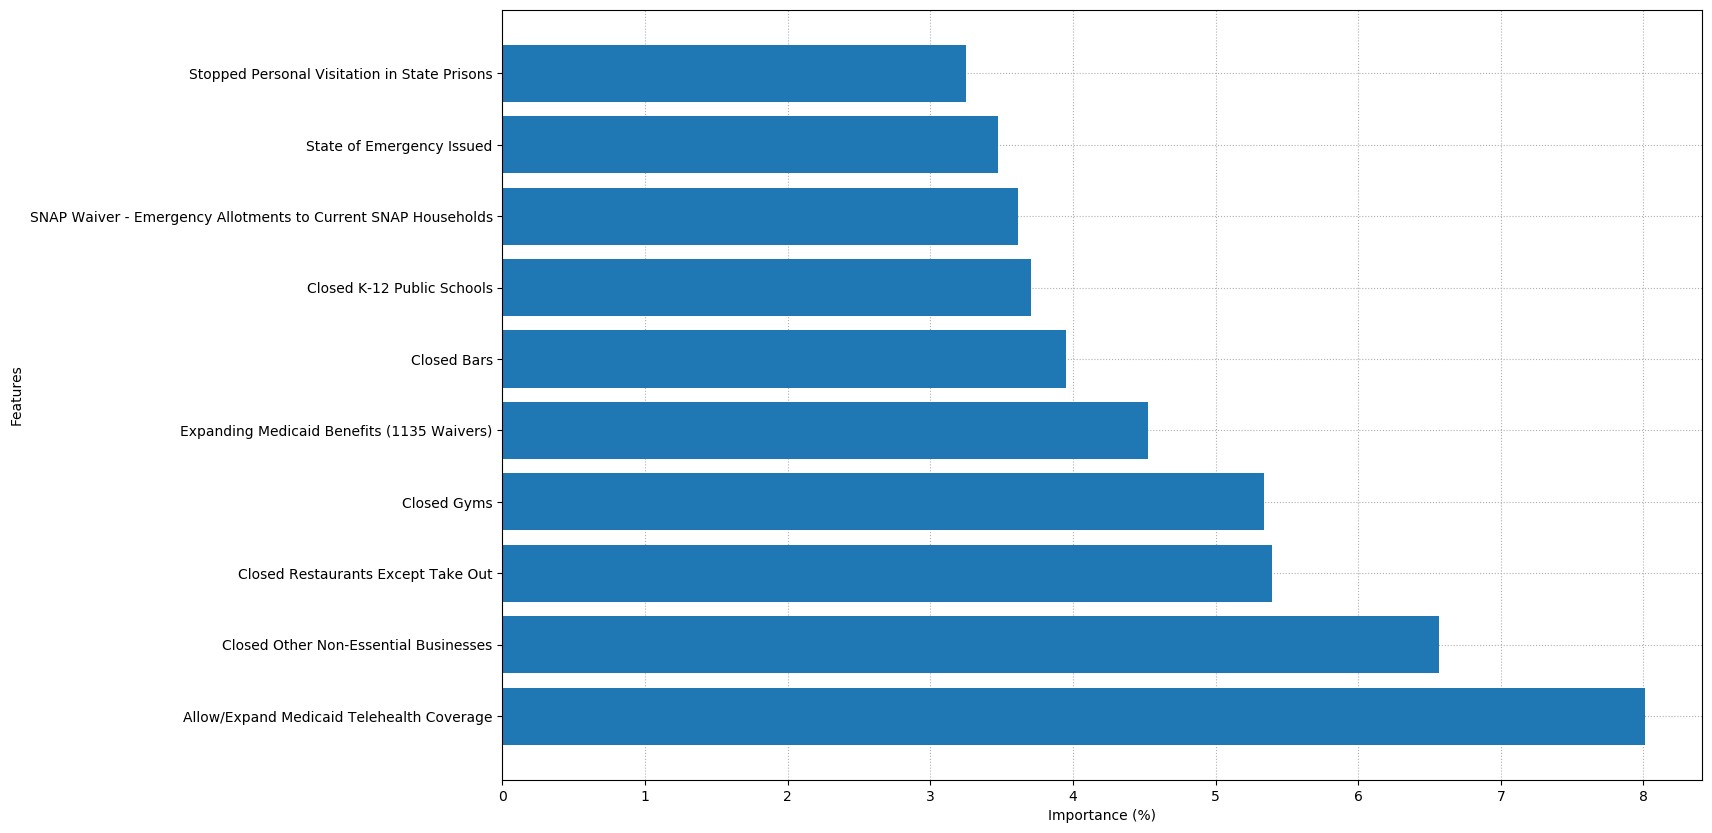

In [9]:
plt.clf()
plt.figure(figsize=(30,10))

to_plot = sorted_feature_importance.head(10)
to_plot.index = new_names_top_10
plt.barh(to_plot.index,to_plot["Importance (%)"], zorder=2)
plt.ylabel("Features")
plt.xlabel("Importance (%)")
plt.legend().set_visible(False)
plt.grid(True,linestyle='dotted',zorder=1)

plt.gcf().subplots_adjust(left=0.5)

plt.savefig("Updated_TLGRF_Top_10_Feature_Importance.png")

plt.show()

In [10]:
sorted_feature_importance.head(10).index

Index(['Stopped_personal_visitation_in_state_prisons',
       'State_of_emergency_issued',
       'SNAP_Waiver_._Emergency_Allotments_to_Current_SNAP_Households',
       'Date_closed_K.12_public_schools', 'Closed_Bars',
       'Modify_Medicaid_requirements_with_1135_waivers_.date_of_CMS_approval.',
       'Closed_gyms', 'Closed_restaurants_except_take_out',
       'Closed_other_non.essential_businesses',
       'Allow.expand_Medicaid_telehealth_coverage'],
      dtype='object')

In [11]:
new_names_top_20 = index_list = [
    'Stopped Personal Visitation in State Prisons',
    'State of Emergency Issued',
    'SNAP Waiver - Emergency Allotments to Current SNAP Households',
    'Closed K-12 Public Schools',
    'Closed Bars',
    'Expanding Medicaid Benefits (1135 Waivers)',
    'Closed Gyms',
    'Closed Restaurants Except Takeout',
    'Closed Other Non-Essential Businesses',
    'Allow/Expand Medicaid Telehealth Coverage',
    'Closed Movie Theaters',
    'Variant - B.1.617.2',
    'Ratio of Positive Tests',
    'Variant - Other',
    'Variant - AY.3',
    'General Public Became Eligible for COVID-19 Vaccination',
    'Adults Ages 30+ Became Eligible for COVID-19 Vaccination',
    'Allowed Restaurants to Sell Takeout Alcohol',
    'Variant - BA.1.1',
    'Adults Ages 80+ Became Eligible for COVID-19 Vaccination'
]

No handles with labels found to put in legend.


<Figure size 640x480 with 0 Axes>

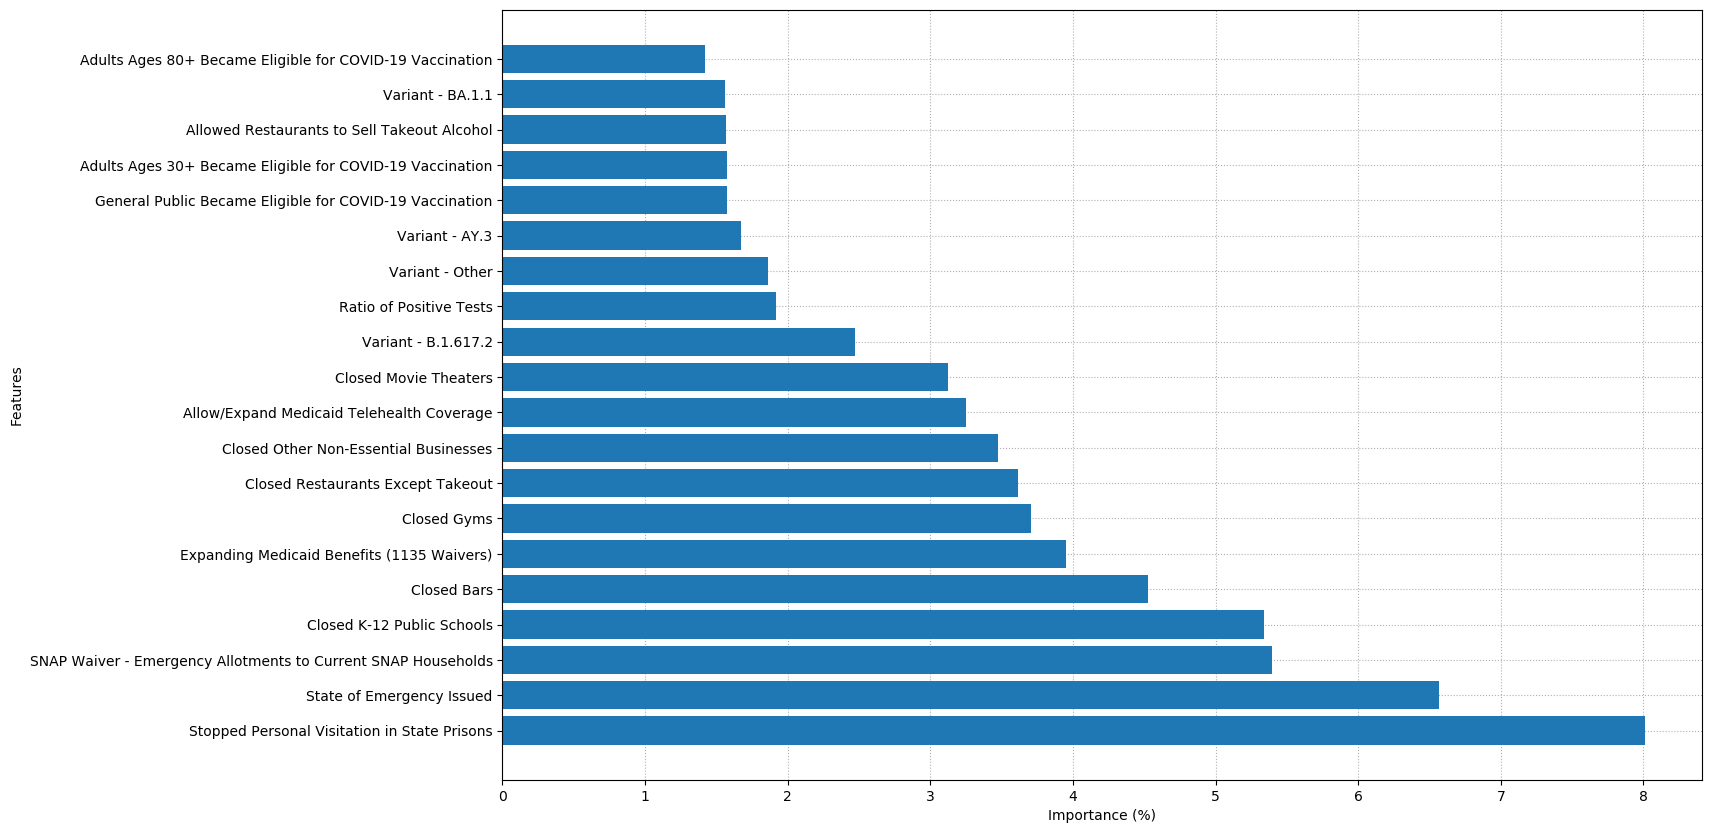

In [12]:
plt.clf()
plt.figure(figsize=(30,10))

to_plot_20 = sorted_feature_importance.head(20)
to_plot_20.index = new_names_top_20
plt.barh(to_plot_20.index,to_plot_20["Importance (%)"], zorder=2)
plt.ylabel("Features")
plt.xlabel("Importance (%)")
plt.legend().set_visible(False)
plt.grid(True,linestyle='dotted',zorder=1)

plt.gcf().subplots_adjust(left=0.5)

plt.savefig("Updated_TLGRF_Top_20_Feature_Importance.png")

plt.show()

In [13]:
(sorted_feature_importance>0).sum()

Importance (%)    398
dtype: int64

In [14]:
sorted_feature_importance.count()

Importance (%)    468
dtype: int64

In [15]:
to_plot_20.sum()

Importance (%)    66.580315
dtype: float64

In [16]:
sorted_feature_importance.to_csv("Sorted_Feature_Importance.csv")

### Anecdotal Descriptions

In [17]:
def display_and_sum_matches(df=to_plot_20, matching_string="Closed|Stopped|Emergency"):
    df = df[df.index.str.contains(matching_string)]
    display(df)
    print(df.sum())

In [18]:
matching_string = "Closed|Stopped|Emergency"
display_and_sum_matches(to_plot_20, matching_string)

,Importance (%)
Stopped Personal Visitation in State Prisons,8.013022
State of Emergency Issued,6.563644
SNAP Waiver - Emergency Allotments to Current SNAP Households,5.398740
Closed K-12 Public Schools,5.341139
Closed Bars,4.523039
Closed Gyms,3.703256
Closed Restaurants Except Takeout,3.615671
Closed Other Non-Essential Businesses,3.477452
Closed Movie Theaters,3.126506


Importance (%)    43.762468
dtype: float64


In [19]:
matching_string = "Expand|Medicare|SNAP"
display_and_sum_matches(to_plot_20, matching_string)

,Importance (%)
SNAP Waiver - Emergency Allotments to Current SNAP Households,5.398740
Expanding Medicaid Benefits (1135 Waivers),3.951363
Allow/Expand Medicaid Telehealth Coverage,3.248397


Importance (%)    12.5985
dtype: float64


In [20]:
matching_string = "Variant|Test"
display_and_sum_matches(to_plot_20, matching_string)

,Importance (%)
Variant - B.1.617.2,2.471407
Ratio of Positive Tests,1.919609
Variant - Other,1.862335
Variant - AY.3,1.671792
Variant - BA.1.1,1.559881


Importance (%)    9.485023
dtype: float64


In [21]:
matching_string = "Vaccination"
display_and_sum_matches(to_plot_20, matching_string)

,Importance (%)
General Public Became Eligible for COVID-19 Vaccination,1.576504
Adults Ages 30+ Became Eligible for COVID-19 Vaccination,1.572880
Adults Ages 80+ Became Eligible for COVID-19 Vaccination,1.417145


Importance (%)    4.56653
dtype: float64
